<a href="https://colab.research.google.com/github/Chahd-TB/AirPassengers-Time-Series-Analysis/blob/main/Touaibia_Chahd_Fatma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd "/content/drive/MyDrive/tp_data_series"

/content/drive/MyDrive/tp_data_series


In [ ]:
import pandas as pd

data = pd.read_csv('AirPassengers.csv')
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


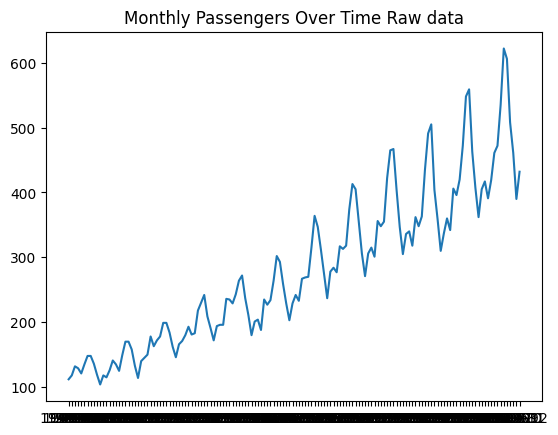

In [ ]:
import matplotlib.pyplot as plt

plt.plot(data['Month'], data['#Passengers'])
plt.title('Monthly Passengers Over Time Raw data')
plt.show()

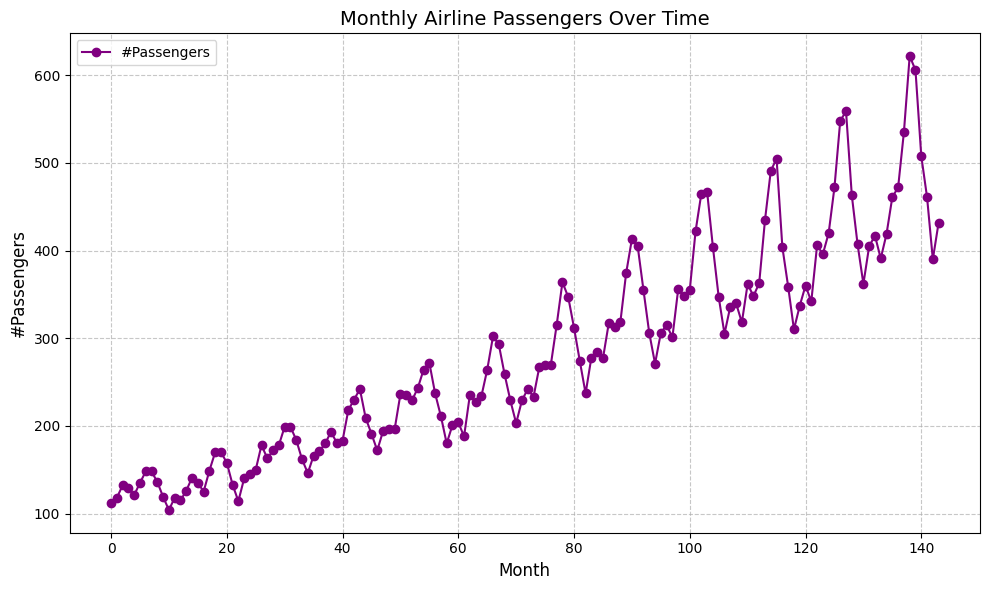

In [ ]:
# Enhanced plot with additional features
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['#Passengers'], marker='o', linestyle='-', color='purple', label='#Passengers')
plt.title('Monthly Airline Passengers Over Time', fontsize=14)  # Larger font for the title
plt.xlabel('Month', fontsize=12)  # Larger font for x-axis label
plt.ylabel('#Passengers', fontsize=12)  # Larger font for y-axis label
plt.legend(fontsize=10)  # Add a legend
plt.grid(True, linestyle='--', alpha=0.7)  # Customize gridlines
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

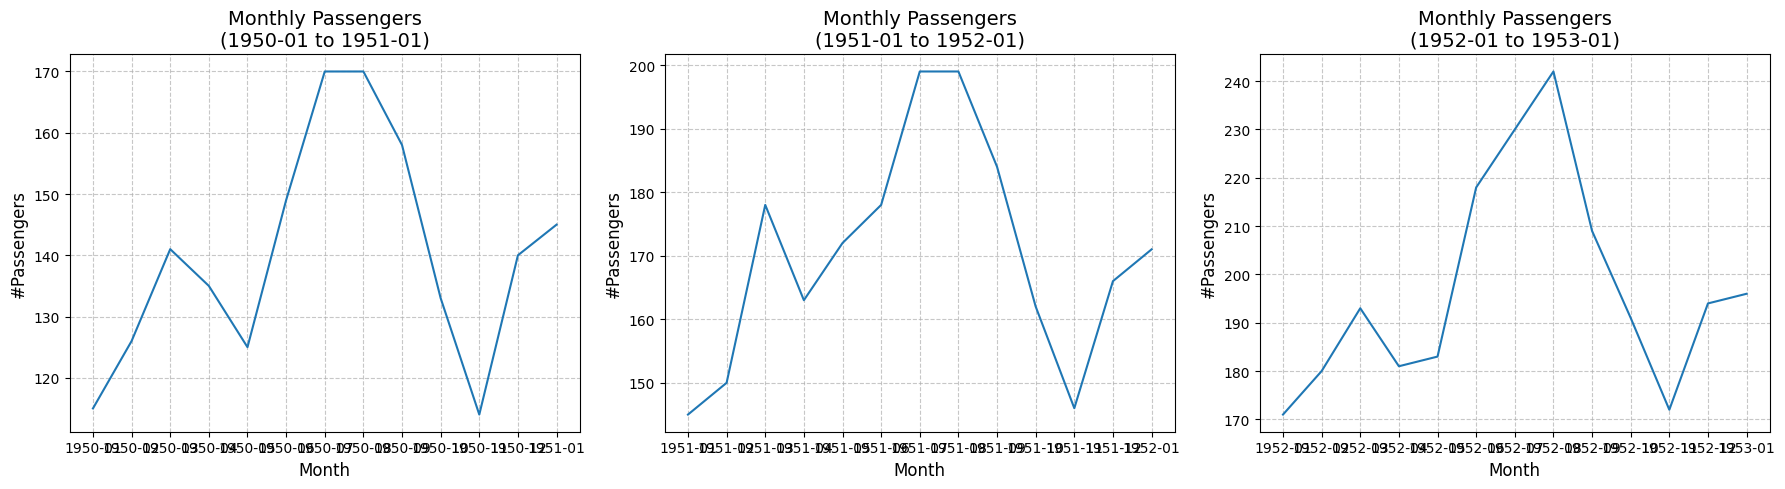

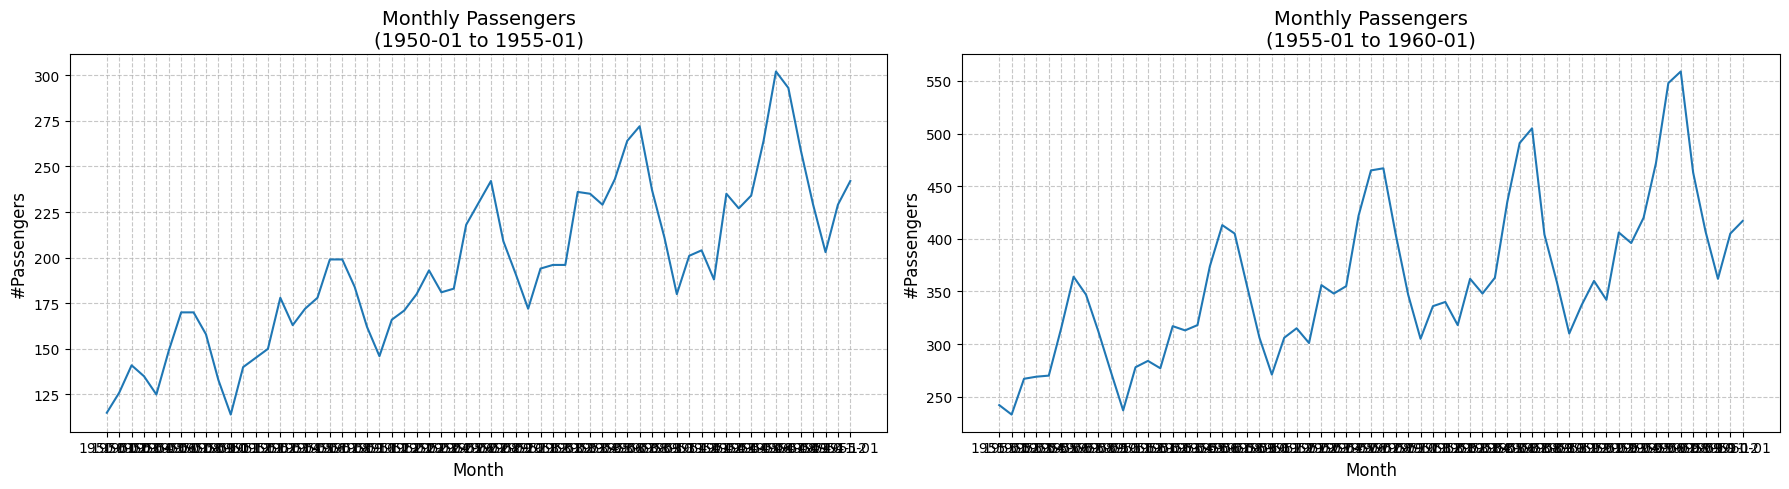

In [ ]:
import matplotlib.pyplot as plt

# Define the time ranges
time_ranges = [
    ('1950-01', '1951-01'),
    ('1951-01', '1952-01'),
    ('1952-01', '1953-01')
]

# Create a figure and axes for the subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Adjust figsize as needed

# Loop through each time range and plot on the corresponding axis
for i, (start_date, end_date) in enumerate(time_ranges):
    # Slice the data for the specific time range
    zoomed_data = data[(data['Month'] >= start_date) & (data['Month'] <= end_date)]

    # Plot the zoomed-in data on the current axis
    axes[i].plot(zoomed_data['Month'], zoomed_data['#Passengers'])
    axes[i].set_title(f'Monthly Passengers\n({start_date} to {end_date})', fontsize=14)
    axes[i].set_xlabel('Month', fontsize=12)
    axes[i].set_ylabel('#Passengers', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


import matplotlib.pyplot as plt

# Define the time ranges
time_ranges = [
    ('1950-01', '1955-01'),
    ('1955-01', '1960-01')
]

# Create a figure and axes for the subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))  # Adjust figsize as needed

# Loop through each time range and plot on the corresponding axis
for i, (start_date, end_date) in enumerate(time_ranges):
    # Slice the data for the specific time range
    zoomed_data = data[(data['Month'] >= start_date) & (data['Month'] <= end_date)]

    # Plot the zoomed-in data on the current axis
    axes[i].plot(zoomed_data['Month'], zoomed_data['#Passengers'])
    axes[i].set_title(f'Monthly Passengers\n({start_date} to {end_date})', fontsize=14)
    axes[i].set_xlabel('Month', fontsize=12)
    axes[i].set_ylabel('#Passengers', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

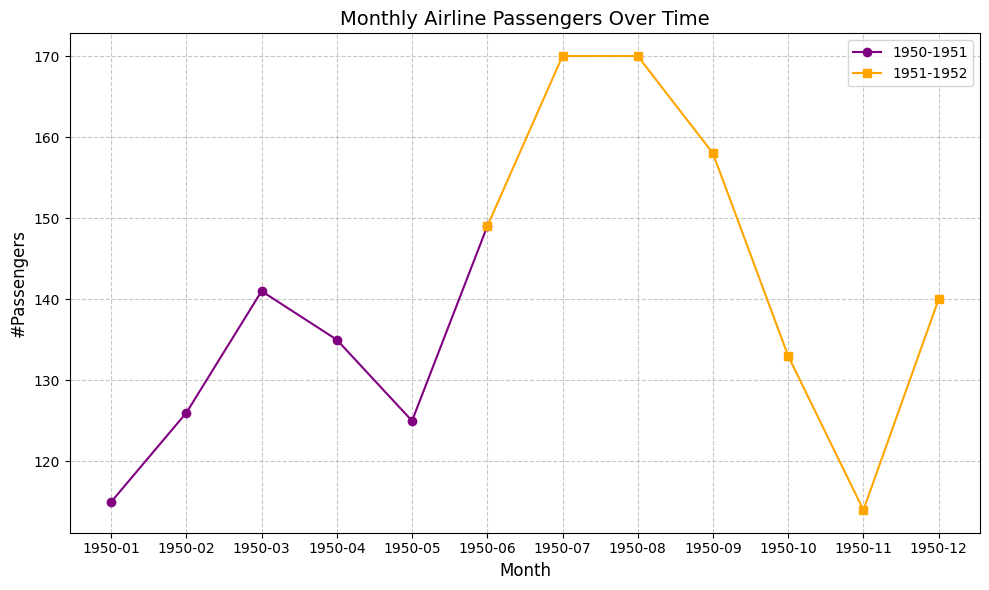

In [ ]:
# Filter the data for the specified time ranges
zoomed_data1 = data[(data['Month'] >= '1950-01') & (data['Month'] <= '1950-06')]
zoomed_data2 = data[(data['Month'] >= '1950-06') & (data['Month'] <= '1950-12')]

# Enhanced plot with additional features
plt.figure(figsize=(10, 6))

# Plot the first time range
plt.plot(zoomed_data1['Month'], zoomed_data1['#Passengers'],
         marker='o', linestyle='-', color='purple', label='1950-1951')

# Plot the second time range
plt.plot(zoomed_data2['Month'], zoomed_data2['#Passengers'],
         marker='s', linestyle='-', color='orange', label='1951-1952')

# Add title and labels
plt.title('Monthly Airline Passengers Over Time', fontsize=14)  # Larger font for the title
plt.xlabel('Month', fontsize=12)  # Larger font for x-axis label
plt.ylabel('#Passengers', fontsize=12)  # Larger font for y-axis label

# Add legend
plt.legend(fontsize=10)  # Add a legend with labels

# Customize gridlines
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

#number of passengers is increasing every year with more than 30 passenger
#there is a repeating pattern every every year the number of passengers increase in mars and december
#the peak is injuly and august
#and the lowest are in january may and november
#i noticed some noise

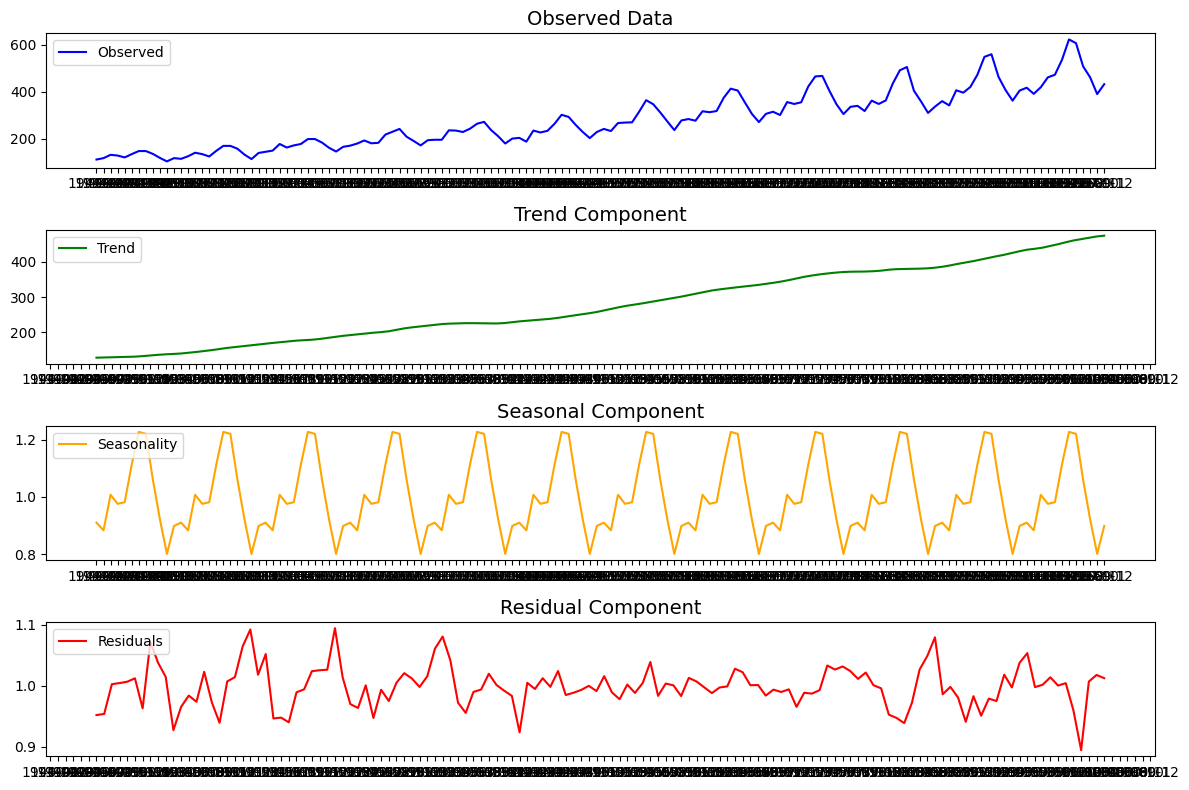

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

data.set_index('Month', inplace=True)

# Perform multiplicative decomposition
decomposition = seasonal_decompose(data['#Passengers'], model='multiplicative', period=12)

# Extract the components
observed = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot the decomposed components
plt.figure(figsize=(12, 8))

# Observed
plt.subplot(4, 1, 1)
plt.plot(observed, label='Observed', color='blue')
plt.title('Observed Data', fontsize=14)
plt.legend(loc='upper left')

# Trend
plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='green')
plt.title('Trend Component', fontsize=14)
plt.legend(loc='upper left')

# Seasonality
plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonality', color='orange')
plt.title('Seasonal Component', fontsize=14)
plt.legend(loc='upper left')

# Residuals
plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals', color='red')
plt.title('Residual Component', fontsize=14)
plt.legend(loc='upper left')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Example: Assume 'data' is your DataFrame with a column '#Passengers'
series = data['#Passengers']

# Perform the ADF test
adf_result = adfuller(series)

# Extract results
adf_statistic = adf_result[0]  # ADF test statistic
p_value = adf_result[1]       # p-value
critical_values = adf_result[4]  # Critical values at different significance levels

# Print results
print(f"ADF Statistic: {adf_statistic}")
print(f"p-value: {p_value}")
print("Critical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value}")

# Interpretation
if p_value < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Critical Values:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598
The time series is non-stationary.


In [ ]:
# Apply second-order differencing
second_diff_series = data['#Passengers'].diff().diff().dropna()

# Perform the ADF test on the second-differenced series
adf_result_second_diff = adfuller(second_diff_series)

# Print results
print(f"ADF Statistic (Second Differenced): {adf_result_second_diff[0]}")
print(f"p-value (Second Differenced): {adf_result_second_diff[1]}")

# Interpretation
if adf_result_second_diff[1] < 0.05:
    print("The second-differenced time series is stationary.")
else:
    print("The second-differenced time series is still non-stationary.")

ADF Statistic (Second Differenced): -16.384231542468513
p-value (Second Differenced): 2.7328918500142026e-29
The second-differenced time series is stationary.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA model
model = ARIMA(data['#Passengers'], order=(1, 1, 1))  # Specify (p, d, q)
results = model.fit()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


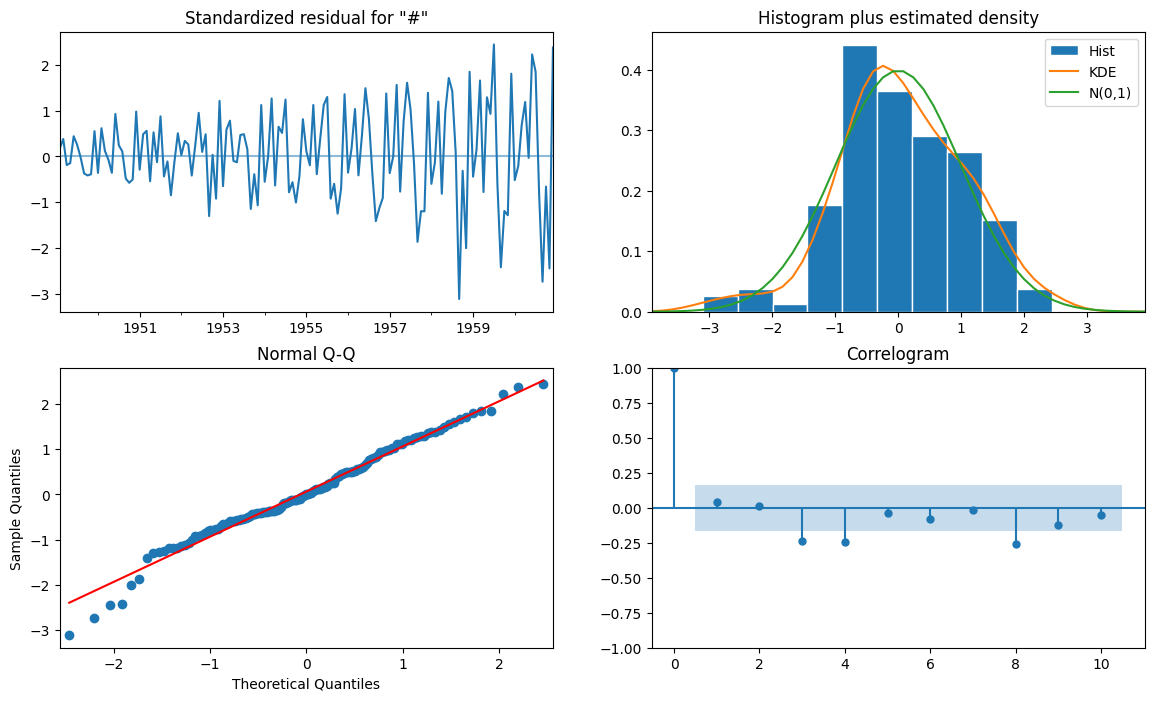

In [ ]:
# Plot the residuals
residuals = results.resid

# Plot diagnostics
results.plot_diagnostics(figsize=(14, 8))
plt.show()

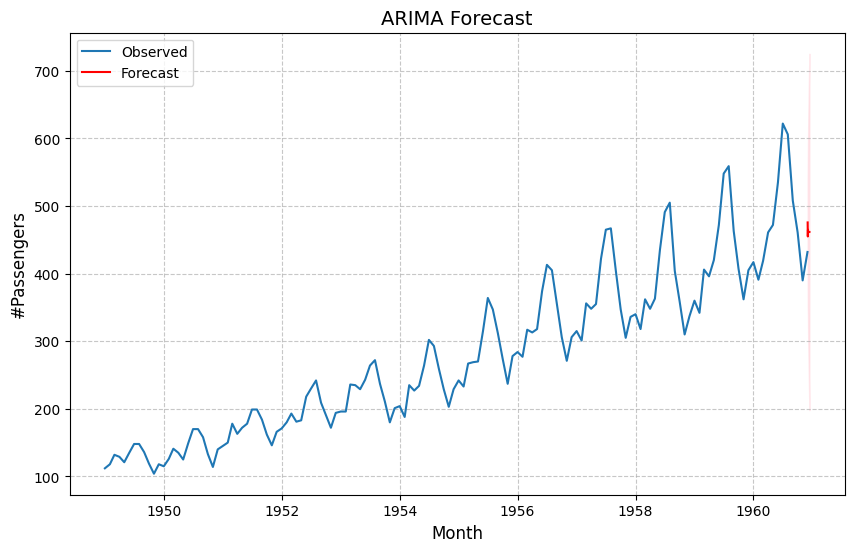

In [ ]:
# Forecast the next 12 months
forecast = results.get_forecast(steps=12)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()  # Confidence intervals

# Ensure all indices are DatetimeIndex
data.index = pd.to_datetime(data.index)  # Convert original data index
forecast_values.index = pd.to_datetime(forecast_values.index)
forecast_ci.index = pd.to_datetime(forecast_ci.index)

# Generate consistent future dates
future_dates = pd.date_range(start=data.index[-1], periods=13, freq=data.index.freq)[1:]  # Exclude last observed date
forecast_values.index = future_dates
forecast_ci.index = future_dates

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['#Passengers'], label='Observed')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA Forecast', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('#Passengers', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(data['#Passengers'], trend='mul', seasonal='mul', seasonal_periods=12)
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


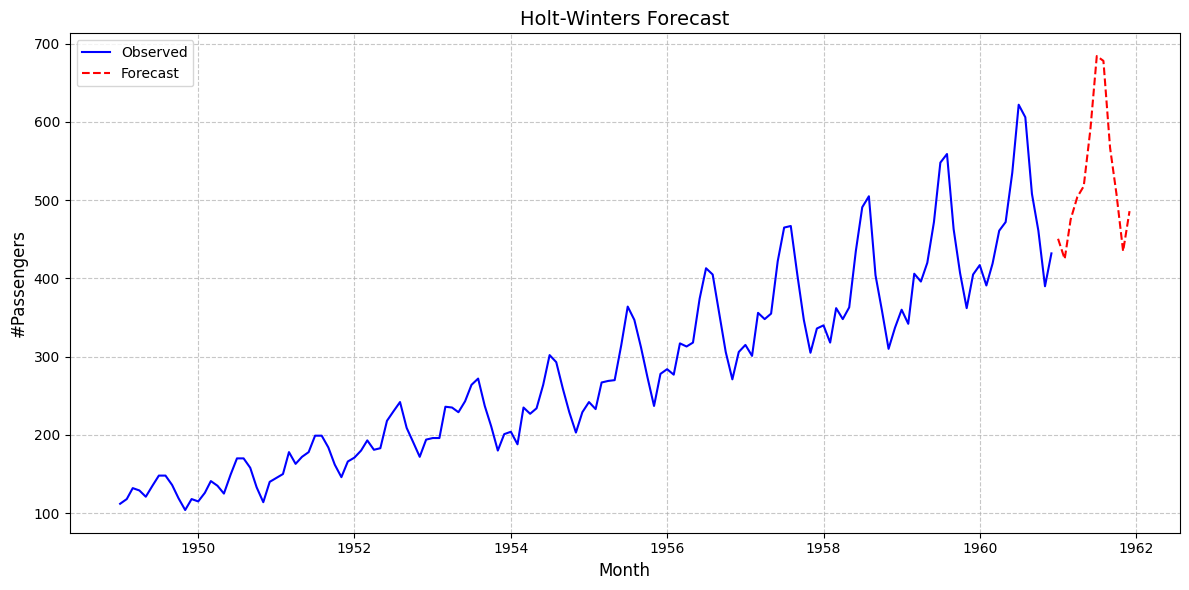

In [ ]:
import matplotlib.pyplot as plt

# Plot observed data
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['#Passengers'], label='Observed', color='blue')

# Plot forecasted values
forecast_index = pd.date_range(start=data.index[-1], periods=13, freq='MS')[1:]  # Future dates
plt.plot(forecast_index, forecast, label='Forecast', color='red', linestyle='--')

# Add labels and title
plt.title('Holt-Winters Forecast', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('#Passengers', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Install Prophet
!pip install prophet

In [ ]:
# Rename columns to 'ds' and 'y'
data['ds'] = data.index  # Use the index which should be 'Month'
data['ds'] = pd.to_datetime(data['ds']) # Convert to datetime
data['y'] = data['#Passengers']  # Rename '#Passengers' to 'y'

# Keep only the required columns
data = data[['ds', 'y']]

# Preview the prepared data
print(data.head())

                   ds    y
Month                     
1949-01-01 1949-01-01  112
1949-02-01 1949-02-01  118
1949-03-01 1949-03-01  132
1949-04-01 1949-04-01  129
1949-05-01 1949-05-01  121


In [ ]:
from prophet import Prophet

# Create and fit the Prophet model
model = Prophet()  # Default settings handle yearly seasonality
model.fit(data)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp71pevmci/53cuhblv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp71pevmci/8j6_0odr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52937', 'data', 'file=/tmp/tmp71pevmci/53cuhblv.json', 'init=/tmp/tmp71pevmci/8j6_0odr.json', 'output', 'file=/tmp/tmp71pevmci/prophet_model7su0h093/prophet_model-20250425224542.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:45:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:45:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Create a dataframe for future dates
future = model.make_future_dataframe(periods=12, freq='MS')  # Forecast next 12 months (monthly frequency)

# Generate predictions
forecast = model.predict(future)

# Preview the forecasted values
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

            ds        yhat  yhat_lower  yhat_upper
151 1961-08-01  577.583651  546.187407  607.502201
152 1961-09-01  529.024494  500.982269  558.996580
153 1961-10-01  493.867634  466.254182  523.819398
154 1961-11-01  460.015755  433.131759  488.579592
155 1961-12-01  489.381680  461.981056  520.971152


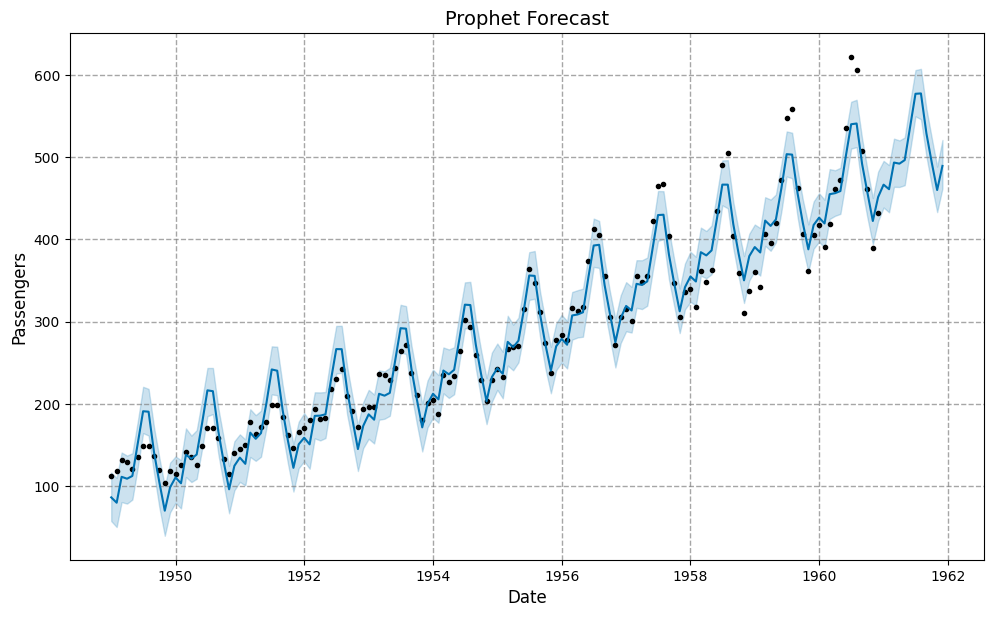

In [ ]:
# Plot the forecast
fig = model.plot(forecast)
plt.title('Prophet Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

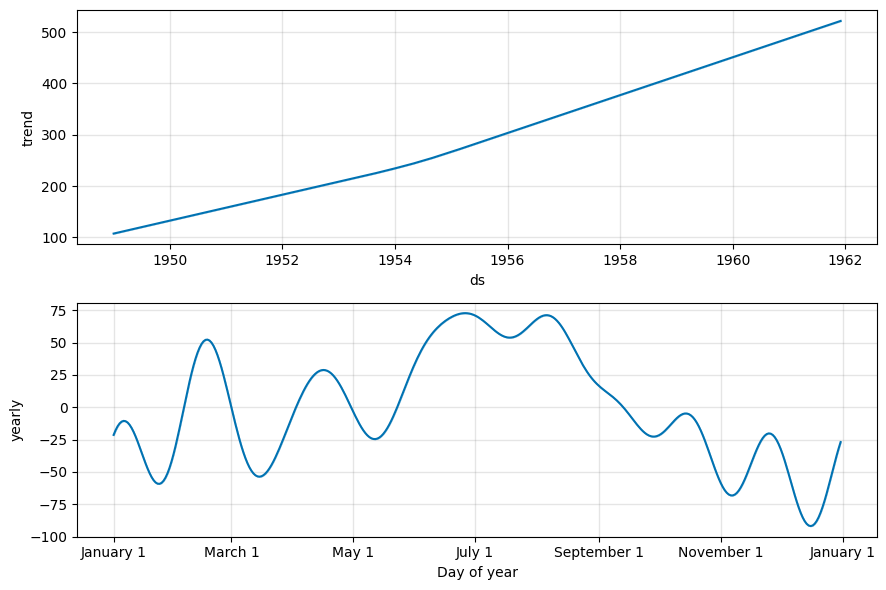

In [ ]:
# Plot components of the forecast
fig = model.plot_components(forecast)
plt.show()